## **Load Credential**

In [1]:
# from dotenv import load_dotenv
# import os
# from pathlib import Path

# env_path = Path('.env')
# print(env_path)
# load_dotenv(dotenv_path=env_path)

# print("Environment variables loaded from .env file")

## **Library**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.parallel import DataParallel, DistributedDataParallel
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts

import talib
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression

import optuna
from optuna.trial import TrialState

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## **Data Loader**

### **Load Data**

In [4]:
# btc2018 = pd.read_csv("../data/btc_usdt_kucoin_2018.csv", parse_dates=["datetime"])
# btc2019 = pd.read_csv("../data/btc_usdt_kucoin_2019.csv", parse_dates=["datetime"])
# btc2020 = pd.read_csv("../data/btc_usdt_kucoin_2020.csv", parse_dates=["datetime"])
# btc2021 = pd.read_csv("../data/btc_usdt_kucoin_2021.csv", parse_dates=["datetime"])
# btc2022 = pd.read_csv("../data/btc_usdt_kucoin_2022.csv", parse_dates=["datetime"])
# btc2023 = pd.read_csv("../data/btc_usdt_kucoin_2023.csv", parse_dates=["datetime"])
# btc2024 = pd.read_csv("../data/btc_usdt_kucoin_2024.csv", parse_dates=["datetime"])
# btc2025 = pd.read_csv("../data/btc_usdt_kucoin_2025.csv", parse_dates=["datetime"])

# xau = pd.read_csv("../data/XAUUSD.csv", sep="\t")

# # fed = pd.read_csv("../data/fed_economic_data_2018_2025.csv")

### **Concatenate DataFrames**

In [5]:
# listbtc = [btc2018, btc2019, btc2020, btc2021, btc2022, btc2023, btc2024, btc2025]
# btc = pd.concat(listbtc, ignore_index=True)
# btc.drop(columns=['timestamp'], inplace=True)
# btc.sort_values(by='datetime', inplace=True)
# btc = btc.drop_duplicates(subset=['datetime'], keep='first')

In [6]:
# full_idx = pd.date_range(
#     start=btc['datetime'].min(),
#     end  =btc['datetime'].max(),
#     freq ='min'
# )

# missing_dates = full_idx.difference(btc['datetime'])

# len(missing_dates)

In [7]:
# xau['datetime'] = pd.to_datetime(xau['Date'].astype(str) + ' ' + xau['Timestamp'], format='%Y%m%d %H:%M:%S')
# xau.drop(['Date', 'Timestamp'], axis=1, inplace=True)
# xau.insert(0, 'datetime', xau.pop('datetime'))


### **Resampling and Fill Missing Values**

In [8]:
# btc.set_index('datetime', inplace=True)

# btc = btc.asfreq('min') 

# rules_fill = {
#     'open': 'ffill',  
#     'high': 'ffill',  
#     'low':  'ffill',  
#     'close':'ffill',  
#     'volume': 0       
# }

# for i, j in rules_fill.items():
#     if j == 0:
#         btc[i] = btc[i].fillna(0)
#     else:
#         btc[i] = btc[i].ffill()

# btc.head()

In [9]:
# xau.set_index('datetime', inplace=True)

# xau = xau.asfreq('min')

# rules_fill = {
#     'Open': 'ffill',  
#     'High': 'ffill',  
#     'Low':  'ffill',  
#     'Close':'ffill',  
#     'Volume': 0       
# }

# for i, j in rules_fill.items():
#     if j == 0:
#         xau[i] = xau[i].fillna(0)
#     else:
#         xau[i] = xau[i].ffill()

# xau.head()

In [10]:
# btc.index = btc.index.tz_localize(None)
# xau.index = xau.index.tz_localize(None)
# fed.index = fed.index.tz_localize(None)

# df = pd.concat([btc, xau], join='inner', axis=1)

# df.rename(columns={'open': 'BTC_Open',
#                 'high': 'BTC_High',
#                 'low': 'BTC_Low',
#                 'close': 'BTC_Close',
#                 'volume': 'BTC_Volume',
#                 'Open': 'XAU_Open',
#                 'High': 'XAU_High',
#                 'Low': 'XAU_Low',
#                 'Close': 'XAU_Close',
#                 'Volume': 'XAU_Volume'}, inplace=True)

In [11]:
# df.info()

In [12]:
# df.describe()

### **Save to Parquet for faster loading**

In [13]:
# df.to_parquet("btc-xau.parquet")

## **Exploratory Data Analysis & Pre-processing**

### **Retrieve Data**

In [6]:
df = pd.read_parquet('btc-xau.parquet')
df.reset_index(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4154397 entries, 0 to 4154396
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   datetime    datetime64[ns]
 1   BTC_Open    float64       
 2   BTC_High    float64       
 3   BTC_Low     float64       
 4   BTC_Close   float64       
 5   BTC_Volume  float64       
 6   XAU_Open    float64       
 7   XAU_High    float64       
 8   XAU_Low     float64       
 9   XAU_Close   float64       
 10  XAU_Volume  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 348.7 MB


In [15]:
df.head()

,datetime,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,XAU_Open,XAU_High,XAU_Low,XAU_Close,XAU_Volume
0,2018-01-01 00:03:00,12933.000001,12933.000001,12933.000001,12933.000001,0.011559,1302.611,1302.722,1302.551,1302.622,0.0
1,2018-01-01 00:04:00,12933.000001,12933.000001,12933.000001,12933.000001,0.000000,1302.611,1302.722,1302.551,1302.622,0.0
2,2018-01-01 00:05:00,12933.000001,12933.000001,12933.000001,12933.000001,0.000000,1302.611,1302.722,1302.551,1302.622,0.0
3,2018-01-01 00:06:00,12933.000001,12933.000001,12933.000001,12933.000001,0.000000,1302.611,1302.722,1302.551,1302.622,0.0
4,2018-01-01 00:07:00,12933.000001,12933.000001,12933.000001,12933.000001,0.000000,1302.611,1302.722,1302.551,1302.622,0.0


### **Data Analysis**

In [16]:
df.describe()

,datetime,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,XAU_Open,XAU_High,XAU_Low,XAU_Close,XAU_Volume
count,4154397,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06,4.154397e+06
mean,2021-12-13 12:01:00.000000256,3.656899e+04,3.658372e+04,3.655436e+04,3.656916e+04,2.977919e+00,1.946557e+03,1.946829e+03,1.946230e+03,1.946494e+03,2.456387e-02
min,2018-01-01 00:03:00,3.160117e+03,3.160117e+03,3.160000e+03,3.160000e+03,0.000000e+00,1.160669e+03,1.160878e+03,1.160168e+03,1.160589e+03,0.000000e+00
25%,2019-12-23 06:02:00,9.380400e+03,9.384200e+03,9.376949e+03,9.380700e+03,2.170021e-01,1.520098e+03,1.520198e+03,1.519998e+03,1.519998e+03,0.000000e+00
50%,2021-12-13 12:01:00,2.699460e+04,2.700180e+04,2.698690e+04,2.699470e+04,9.818153e-01,1.823938e+03,1.824185e+03,1.823688e+03,1.823927e+03,1.264000e-02
75%,2023-12-04 18:00:00,5.619120e+04,5.622780e+04,5.615520e+04,5.619150e+04,3.072738e+00,2.020374e+03,2.020598e+03,2.020118e+03,2.020348e+03,3.501000e-02
max,2025-11-24 23:59:00,1.261065e+05,1.261854e+05,1.260581e+05,1.261066e+05,1.000632e+03,4.380455e+03,4.381298e+03,4.377585e+03,4.380415e+03,3.205280e+00
std,NaN,3.186956e+04,3.187899e+04,3.185994e+04,3.186943e+04,7.601513e+00,6.205409e+02,6.206773e+02,6.203826e+02,6.205099e+02,3.485011e-02


In [17]:
# fig = go.Figure()
# fig.add_trace(go.Candlestick(x=df.index,
#                 open=df['BTC_Open'],
#                 high=df['BTC_High'],
#                 low=df['BTC_Low'],
#                 close=df['BTC_Close'],
#                 name='BTC/USDT'))
# fig.update_layout(title='BTC Price (BTC/USDT)', xaxis_title='Date', yaxis_title='Price (USDT)', template='plotly_dark',)
# fig.show()

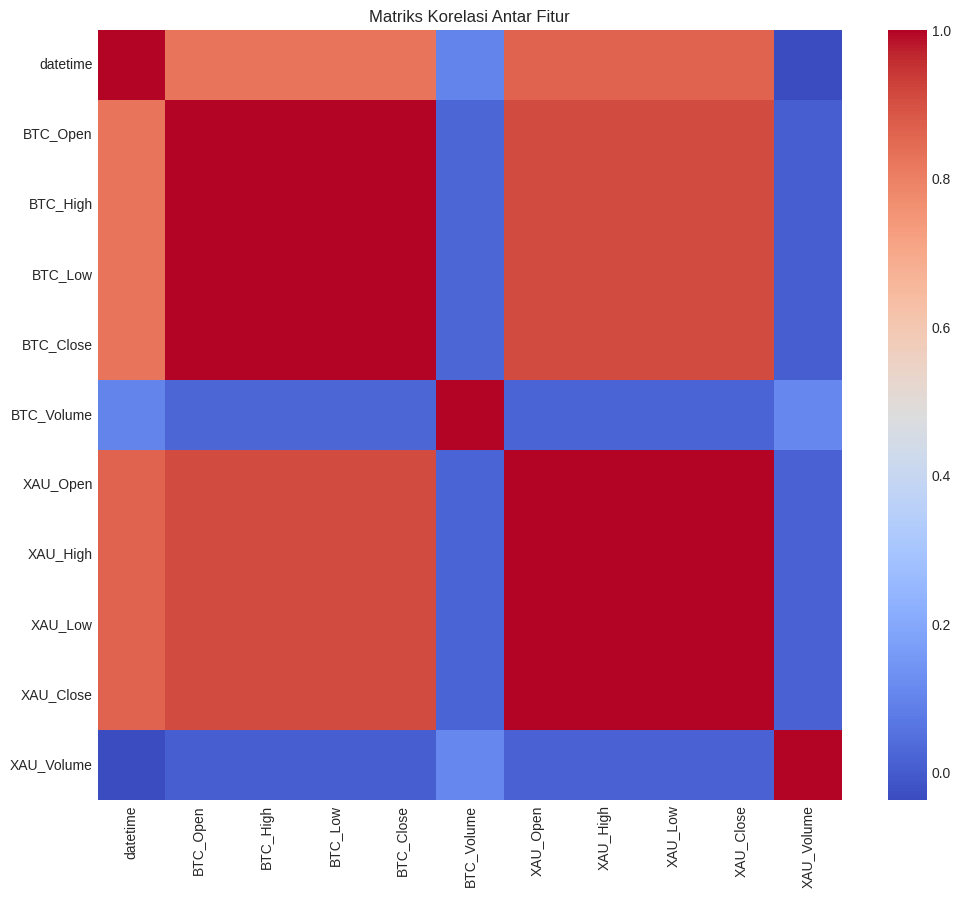

In [18]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".4f")
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

### **Data Cleaning**

## **Features Engineering and Features Selection**

### **Set Seed**

In [2]:
SEED = 819
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f"Available GPUs: {n_gpus}")
print(f"Device: {device}")

Available GPUs: 0
Device: cpu


### **Features Engineering**

#### **Technical Indicators (BTCUSDT)**

In [7]:
# Price-based features
df['BTC_Returns'] = df['BTC_Close'].pct_change()
df['BTC_Log_Returns'] = np.log(df['BTC_Close'] / df['BTC_Close'].shift(1))
df['BTC_Range'] = df['BTC_High'] - df['BTC_Low']
df['BTC_Range_Pct'] = df['BTC_Range'] / df['BTC_Close']
df['BTC_HL_Spread'] = (df['BTC_High'] - df['BTC_Low']) / df['BTC_Open']

# Body and shadows (candlestick patterns)
df['BTC_Body'] = abs(df['BTC_Close'] - df['BTC_Open'])
df['BTC_Upper_Shadow'] = df['BTC_High'] - df[['BTC_Open', 'BTC_Close']].max(axis=1)
df['BTC_Lower_Shadow'] = df[['BTC_Open', 'BTC_Close']].min(axis=1) - df['BTC_Low']
df['BTC_Body_Ratio'] = df['BTC_Body'] / (df['BTC_Range'] + 1e-10)

# Moving Averages
for window in [5, 10, 20, 30, 60, 120, 240]:
    df[f'BTC_SMA_{window}'] = df['BTC_Close'].rolling(window).mean()
    df[f'BTC_EMA_{window}'] = df['BTC_Close'].ewm(span=window, adjust=False).mean()
    df[f'BTC_Price_to_SMA_{window}'] = df['BTC_Close'] / df[f'BTC_SMA_{window}']
    df[f'BTC_Dist_SMA_{window}'] = (df['BTC_Close'] - df[f'BTC_SMA_{window}']) / df[f'BTC_SMA_{window}']

df['BTC_SMA_Cross_5_20'] = (df['BTC_SMA_5'] - df['BTC_SMA_20']) / df['BTC_SMA_20']
df['BTC_SMA_Cross_10_30'] = (df['BTC_SMA_10'] - df['BTC_SMA_30']) / df['BTC_SMA_30']
df['BTC_EMA_Cross_5_20'] = (df['BTC_EMA_5'] - df['BTC_EMA_20']) / df['BTC_EMA_20']

# Volatility
for window in [5, 10, 20, 60]:
    df[f'BTC_Volatility_{window}'] = df['BTC_Returns'].rolling(window).std()
    df[f'BTC_ATR_{window}'] = talib.ATR(df['BTC_High'].values, 
                                            df['BTC_Low'].values, 
                                            df['BTC_Close'].values, 
                                            timeperiod=window)
    df[f'BTC_ATR_Pct_{window}'] = df[f'BTC_ATR_{window}'] / df['BTC_Close']

# Historical Volatility (Parkinson estimator)
for window in [10, 20, 60]:
    hl_ratio = np.log(df['BTC_High'] / df['BTC_Low'])
    df[f'BTC_Parkinson_Vol_{window}'] = np.sqrt(
        hl_ratio.rolling(window).apply(lambda x: np.sum(x**2) / (4 * window * np.log(2)))
    )

# Momentum Indicators
for period in [7, 14, 21, 28]:
    df[f'BTC_RSI_{period}'] = talib.RSI(df['BTC_Close'].values, timeperiod=period)

# MACD
macd, signal, hist = talib.MACD(df['BTC_Close'].values, 
                                    fastperiod=12, 
                                    slowperiod=26, 
                                    signalperiod=9)
df['BTC_MACD'] = macd
df['BTC_MACD_Signal'] = signal
df['BTC_MACD_Hist'] = hist
df['BTC_MACD_Diff'] = df['BTC_MACD'] - df['BTC_MACD_Signal']

# Stochastic
slowk, slowd = talib.STOCH(df['BTC_High'].values, 
                            df['BTC_Low'].values, 
                            df['BTC_Close'].values,
                            fastk_period=14,
                            slowk_period=3,
                            slowd_period=3)
df['BTC_Stoch_K'] = slowk
df['BTC_Stoch_D'] = slowd
df['BTC_Stoch_Diff'] = slowk - slowd

# ROC (Rate of Change)
for period in [5, 10, 20]:
    df[f'BTC_ROC_{period}'] = talib.ROC(df['BTC_Close'].values, timeperiod=period)

# Momentum
for period in [5, 10, 20]:
    df[f'BTC_MOM_{period}'] = talib.MOM(df['BTC_Close'].values, timeperiod=period)

# Williams %R
for period in [14, 28]:
    df[f'BTC_WILLR_{period}'] = talib.WILLR(
        df['BTC_High'].values,
        df['BTC_Low'].values,
        df['BTC_Close'].values,
        timeperiod=period
    )

# CCI (Commodity Channel Index)
for period in [14, 20]:
    df[f'BTC_CCI_{period}'] = talib.CCI(
        df['BTC_High'].values,
        df['BTC_Low'].values,
        df['BTC_Close'].values,
        timeperiod=period
    )

# Bollinger Bands
for period in [10, 20, 30]:
    upper, middle, lower = talib.BBANDS(
        df['BTC_Close'].values,
        timeperiod=period,
        nbdevup=2,
        nbdevdn=2
    )
    df[f'BTC_BB_Upper_{period}'] = upper
    df[f'BTC_BB_Middle_{period}'] = middle
    df[f'BTC_BB_Lower_{period}'] = lower
    df[f'BTC_BB_Width_{period}'] = (upper - lower) / middle
    df[f'BTC_BB_Position_{period}'] = (df['BTC_Close'] - lower) / (upper - lower + 1e-10)
    df[f'BTC_BB_UpperDist_{period}'] = (upper - df['BTC_Close']) / df['BTC_Close']
    df[f'BTC_BB_LowerDist_{period}'] = (df['BTC_Close'] - lower) / df['BTC_Close']


# Volume Indicators
for window in [5, 10, 20, 60]:
    df[f'BTC_Volume_SMA_{window}'] = df['BTC_Volume'].rolling(window).mean()
    df[f'BTC_Volume_Ratio_{window}'] = df['BTC_Volume'] / (df[f'BTC_Volume_SMA_{window}'] + 1e-10)

# On-Balance Volume (OBV)
df['BTC_OBV'] = talib.OBV(df['BTC_Close'].values, df['BTC_Volume'].values)
df['BTC_OBV_SMA_20'] = df['BTC_OBV'].rolling(20).mean()

# Chaikin Money Flow (CMF)
df['BTC_CMF'] = talib.ADOSC(
    df['BTC_High'].values,
    df['BTC_Low'].values,
    df['BTC_Close'].values,
    df['BTC_Volume'].values,
    fastperiod=3,
    slowperiod=10
)

# Volume-Weighted Average Price (VWAP) approximation
for window in [20, 60]:
    df[f'BTC_VWAP_{window}'] = (
        (df['BTC_Close'] * df['BTC_Volume']).rolling(window).sum() /
        df['BTC_Volume'].rolling(window).sum()
    )
    df[f'BTC_Price_to_VWAP_{window}'] = df['BTC_Close'] / df[f'BTC_VWAP_{window}']

# Money Flow Index (MFI)
df['BTC_MFI_14'] = talib.MFI(
    df['BTC_High'].values,
    df['BTC_Low'].values,
    df['BTC_Close'].values,
    df['BTC_Volume'].values,
    timeperiod=14
)

#### **Technical Indicators (XAUUSD)**

In [8]:
df['XAU_Returns'] = df['XAU_Close'].pct_change()
df['XAU_Log_Returns'] = np.log(df['XAU_Close'] / df['XAU_Close'].shift(1))
df['XAU_Range'] = df['XAU_High'] - df['XAU_Low']
df['XAU_Range_Pct'] = df['XAU_Range'] / df['XAU_Close']

xau_ma_windows = [5, 10, 20, 30, 60, 120]
for window in xau_ma_windows:
    df[f'XAU_SMA_{window}'] = df['XAU_Close'].rolling(window).mean()
    df[f'XAU_EMA_{window}'] = df['XAU_Close'].ewm(span=window, adjust=False).mean()
    df[f'XAU_Price_to_SMA_{window}'] = df['XAU_Close'] / df[f'XAU_SMA_{window}']

for window in [5, 10, 20, 60]:
    df[f'XAU_Volatility_{window}'] = df['XAU_Returns'].rolling(window).std()
    df[f'XAU_ATR_{window}'] = talib.ATR(
        df['XAU_High'].values,
        df['XAU_Low'].values,
        df['XAU_Close'].values,
        timeperiod=window
    )

df['XAU_RSI_14'] = talib.RSI(df['XAU_Close'].values, timeperiod=14)
df['XAU_RSI_7'] = talib.RSI(df['XAU_Close'].values, timeperiod=7)

xau_macd, xau_signal, xau_hist = talib.MACD(
    df['XAU_Close'].values,
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)
df['XAU_MACD'] = xau_macd
df['XAU_MACD_Signal'] = xau_signal
df['XAU_MACD_Hist'] = xau_hist

for period in [5, 10, 20]:
    df[f'XAU_ROC_{period}'] = talib.ROC(df['XAU_Close'].values, timeperiod=period)

#### **Temporal Features**

In [9]:
# Basic time features
df['Hour'] = df['datetime'].dt.hour
df['Minute'] = df['datetime'].dt.minute
df['DayOfWeek'] = df['datetime'].dt.dayofweek
df['DayOfMonth'] = df['datetime'].dt.day
df['Month'] = df['datetime'].dt.month
df['Quarter'] = df['datetime'].dt.quarter
df['DayOfYear'] = df['datetime'].dt.dayofyear
df['WeekOfYear'] = df['datetime'].dt.isocalendar().week

# Cyclical encoding (important for neural networks)
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['Minute_Sin'] = np.sin(2 * np.pi * df['Minute'] / 60)
df['Minute_Cos'] = np.cos(2 * np.pi * df['Minute'] / 60)
df['DayOfWeek_Sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_Cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfYear_Sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DayOfYear_Cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# Trading session indicators (crypto-specific)
# Asian session: 0-8 UTC, European: 8-16 UTC, US: 16-24 UTC
df['Asian_Session'] = ((df['Hour'] >= 0) & (df['Hour'] < 8)).astype(int)
df['European_Session'] = ((df['Hour'] >= 8) & (df['Hour'] < 16)).astype(int)
df['US_Session'] = ((df['Hour'] >= 16) & (df['Hour'] < 24)).astype(int)

# Weekend indicator
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Market opening hours (traditional markets)
df['NYSE_Hours'] = ((df['Hour'] >= 14) & (df['Hour'] < 21)).astype(int)

print(f"New shape: {df.shape}")

New shape: (4154397, 185)


#### **Lag Features**

In [10]:
for lag in [1, 2, 3, 5, 10, 20, 30, 60]:
    df[f'BTC_Close_Lag_{lag}'] = df['BTC_Close'].shift(lag)
    df[f'BTC_Returns_Lag_{lag}'] = df['BTC_Returns'].shift(lag)
    df[f'XAU_Returns_Lag_{lag}'] = df['XAU_Returns'].shift(lag)
    df[f'BTC_Volume_Lag_{lag}'] = df['BTC_Volume'].shift(lag)

print(f"New shape: {df.shape}")

New shape: (4154397, 217)


#### **Rolling Window**

In [12]:
stat_windows = [10, 20, 60, 120]

for window in stat_windows:
    # Returns statistics
    df[f'BTC_Returns_Mean_{window}'] = df['BTC_Returns'].rolling(window).mean()
    df[f'BTC_Returns_Std_{window}'] = df['BTC_Returns'].rolling(window).std()
    df[f'BTC_Returns_Skew_{window}'] = df['BTC_Returns'].rolling(window).skew()
    df[f'BTC_Returns_Kurt_{window}'] = df['BTC_Returns'].rolling(window).kurt()
    
    # Price statistics
    df[f'BTC_Price_Min_{window}'] = df['BTC_Close'].rolling(window).min()
    df[f'BTC_Price_Max_{window}'] = df['BTC_Close'].rolling(window).max()
    df[f'BTC_Price_Range_{window}'] = df[f'BTC_Price_Max_{window}'] - df[f'BTC_Price_Min_{window}']
    
    # Quantiles
    df[f'BTC_Price_Q25_{window}'] = df['BTC_Close'].rolling(window).quantile(0.25)
    df[f'BTC_Price_Q75_{window}'] = df['BTC_Close'].rolling(window).quantile(0.75)
    df[f'BTC_Price_IQR_{window}'] = df[f'BTC_Price_Q75_{window}'] - df[f'BTC_Price_Q25_{window}']


#### **Target Variable Creation**

In [13]:
FORECAST_HORIZONS = [1, 5, 10, 15, 30, 60]
PRIMARY_HORIZON = 15

print(f"Creating target variables for horizons: {FORECAST_HORIZONS} minutes\n")

for horizon in FORECAST_HORIZONS:
    # Future price
    df[f'Target_Price_{horizon}m'] = df['BTC_Close'].shift(-horizon)
    
    # Future return
    df[f'Target_Return_{horizon}m'] = (
        df[f'Target_Price_{horizon}m'] - df['BTC_Close']
    ) / df['BTC_Close']
    
    # Direction (for Directional Accuracy)
    df[f'Target_Direction_{horizon}m'] = (
        df[f'Target_Return_{horizon}m'] > 0
    ).astype(int)
    
    # Price change
    df[f'Target_Change_{horizon}m'] = df[f'Target_Price_{horizon}m'] - df['BTC_Close']

# Define primary targets
TARGET_COL = f'Target_Price_{PRIMARY_HORIZON}m'
DIRECTION_COL = f'Target_Direction_{PRIMARY_HORIZON}m'
RETURN_COL = f'Target_Return_{PRIMARY_HORIZON}m'

Creating target variables for horizons: [1, 5, 10, 15, 30, 60] minutes



### **Data Cleaning**

In [14]:
print(f"Original dataset shape: {df.shape}")

# Remove rows with NaN
nan_counts = df.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) > 0:
    print(f"Columns with NaN values: {len(nan_cols)}")
    print(f"Total NaN values: {nan_counts.sum()}")

df = df.dropna().reset_index(drop=True)
print(f"After removing NaN: {df.shape}")
print(f"Rows removed: {len(df) - len(df):,} ({(len(df) - len(df))/len(df)*100:.2f}%)")

# Remove infinite values
print(f"\nChecking for infinite values...")
inf_mask = np.isinf(df.select_dtypes(include=[np.number]).values).any(axis=1)
if inf_mask.sum() > 0:
    print(f"Rows with infinite values: {inf_mask.sum()}")
    df = df[~inf_mask].reset_index(drop=True)
    print(f"After removing infinite values: {df.shape}")

# # Verify target distribution
# print(f"\nTarget Distribution Analysis:")
# direction_dist = df[DIRECTION_COL].value_counts(normalize=True)
# print(f"Direction distribution:")
# print(f"  Up (1):   {direction_dist.get(1, 0)*100:.2f}%")
# print(f"  Down (0): {direction_dist.get(0, 0)*100:.2f}%")

# # Check for class imbalance
# if abs(direction_dist.get(1, 0.5) - 0.5) > 0.15:
#     print(f"  ⚠️  Warning: Significant class imbalance detected!")
# else:
#     print(f"  ✓ Classes are reasonably balanced")

print(f"Final dataset shape: {df.shape}")

Original dataset shape: (4154397, 281)
Columns with NaN values: 217
Total NaN values: 39884


MemoryError: Unable to allocate 8.06 GiB for an array with shape (261, 4143704) and data type float64

### **Features Selection**

#### **Separate features and target**

In [ ]:
exclude_cols = ['datetime'] + [col for col in df.columns if 'Target_' in col]
feature_cols_all = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols_all]
y = df[TARGET_COL]

print(f"Feature columns: {feature_cols_all} \nLength: {len(feature_cols_all)}")
print(f"Target column: {TARGET_COL}\nLength: {len(TARGET_COL)}")

In [28]:
X.shape

(4154157, 124)

In [29]:
y.shape

(4154157,)

#### **Remove highly correlated features**

In [ ]:
# Calculate correlation matrix
corr_matrix = X_all.corr().abs()

# Find features with correlation > 0.95
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]

print(f"   Features to remove due to high correlation: {len(to_drop)}")

X_reduced = X_all.drop(columns=to_drop)
print(f"   Remaining features: {X_reduced.shape[1]}")

#### **Mutual information for feature importance**

In [ ]:
# Calculate MI scores
mi_scores = mutual_info_regression(
    X_reduced,
    y_target,
    random_state=SEED,
    n_neighbors=5
)

mi_scores_series = pd.Series(mi_scores, index=X_reduced.columns).sort_values(ascending=False)

In [ ]:
TOP_N_FEATURES = min(150, len(mi_scores_series))  # Top 100 or all if less
selected_features = mi_scores_series.head(TOP_N_FEATURES).index.tolist()

print(f"   Selected top {TOP_N_FEATURES} features based on Mutual Information")

print(f"\nTop 30 Most Important Features:")
print(f"{'='*70}")
print(f"{'Rank':<6} {'Feature':<45} {'MI Score':<15}")
print(f"{'-'*70}")
for i, (feat, score) in enumerate(mi_scores_series.head(30).items(), 1):
    print(f"{i:<6} {feat:<45} {score:.6f}")
print(f"{'='*70}")

# Final feature set
FEATURE_COLS = selected_features

print(f"\n✓ Feature selection complete")
print(f"Final feature count: {len(FEATURE_COLS)}")
print(f"{'='*80}\n")

## **Data Preparation and Scaling**

### **Data Prep**

In [34]:
print("Hello World")

Hello World


In [ ]:
train_size = int(0.70 * len(df))
val_size = int(0.15 * len(df))

df_train = df.iloc[:train_size]
df_val = df.iloc[train_size:train_size+val_size]
df_test = df.iloc[train_size+val_size:]

print(f"Train: {len(df_train)} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val:   {len(df_val)} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test)} samples ({len(df_test)/len(df)*100:.1f}%)")

scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_train_scaled = scaler_X.fit_transform(df_train[FEATURE_COLS])
y_train_scaled = scaler_y.fit_transform(df_train[[TARGET_COL]])

X_val_scaled = scaler_X.transform(df_val[FEATURE_COLS])
y_val_scaled = scaler_y.transform(df_val[[TARGET_COL]])

X_test_scaled = scaler_X.transform(df_test[FEATURE_COLS])
y_test_scaled = scaler_y.transform(df_test[[TARGET_COL]])

print(f"Feature shape: {X_train_scaled.shape}")
print(f"Target shape: {y_train_scaled.shape}")

Train: 2907909 samples (70.0%)
Val:   623123 samples (15.0%)
Test:  623125 samples (15.0%)


### **Timeseries Dataset**

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, directions, sequence_length=60):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.directions = torch.LongTensor(directions)
        self.sequence_length = sequence_length
        
    def __len__(self):
        return len(self.X) - self.sequence_length
    
    def __getitem__(self, idx):
        X_seq = self.X[idx:idx+self.sequence_length]
        
        y_target = self.y[idx+self.sequence_length]
        direction = self.directions[idx+self.sequence_length]
        
        return X_seq, y_target, direction

SEQUENCE_LENGTH = 360

train_dataset = TimeSeriesDataset(
    X_train_scaled, 
    y_train_scaled.flatten(),
    df_train[DIRECTION_COL].values,
    sequence_length=SEQUENCE_LENGTH
)

val_dataset = TimeSeriesDataset(
    X_val_scaled,
    y_val_scaled.flatten(),
    df_val[DIRECTION_COL].values,
    sequence_length=SEQUENCE_LENGTH
)

test_dataset = TimeSeriesDataset(
    X_test_scaled,
    y_test_scaled.flatten(),
    df_test[DIRECTION_COL].values,
    sequence_length=SEQUENCE_LENGTH
)

print(f"Train sequences: {len(train_dataset)}")
print(f"Val sequences:   {len(val_dataset)}")
print(f"Test sequences:  {len(test_dataset)}")

# Verify dataset sample
sample_X, sample_y, sample_d = train_dataset[0]
print(f"\nSample Verification:")
print(f"  X shape: {sample_X.shape} (sequence_length, num_features)")
print(f"  y shape: {sample_y.shape} (scalar)")
print(f"  direction shape: {sample_d.shape} (scalar)")

config = {
    'feature_cols': FEATURE_COLS,
    'target_col': TARGET_COL,
    'direction_col': DIRECTION_COL,
    'sequence_length': SEQUENCE_LENGTH,
    'primary_horizon': PRIMARY_HORIZON,
    'num_features': len(FEATURE_COLS),
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset)
}

Train sequences: 2907549
Val sequences:   622763
Test sequences:  622765


## **Temporal Fusion Transformers Model Architecture**

### **Gated Residual Networks**

In [ ]:
class GatedResidualNetwork(nn.Module):    
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1, context_dim=None):
        super().__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.context_dim = context_dim
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
        if context_dim is not None:
            self.context_fc = nn.Linear(context_dim, hidden_dim)
        
        self.gate_fc = nn.Linear(hidden_dim, output_dim)
        
        self.layer_norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)
        
        if input_dim != output_dim:
            self.skip_layer = nn.Linear(input_dim, output_dim)
        else:
            self.skip_layer = None
    
    def forward(self, x, context=None):
        h = F.elu(self.fc1(x))
        
        if context is not None and self.context_dim is not None:
            h = h + self.context_fc(context)
        
        h = self.dropout(h)
        h = self.fc2(h)
        
        gate_input = F.elu(self.fc1(x))
        if context is not None and self.context_dim is not None:
            gate_input = gate_input + self.context_fc(context)
        gate = torch.sigmoid(self.gate_fc(gate_input))
        
        gated_output = gate * h
        
        if self.skip_layer is not None:
            skip = self.skip_layer(x)
        else:
            skip = x
        
        output = self.layer_norm(gated_output + skip)
        
        return output

### **Variable Selection Network**

In [ ]:
class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        
        self.grns = nn.ModuleList([
            GatedResidualNetwork(1, hidden_dim, hidden_dim, dropout)
            for _ in range(input_dim)
        ])
        
        self.feature_weight_network = nn.Sequential(
            nn.Linear(hidden_dim * input_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
        
        self.softmax = nn.Softmax(dim=-1)
        
    def forward(self, x):
        batch_size, seq_len, num_features = x.shape
        
        processed_features = []
        for i, grn in enumerate(self.grns):
            feature = x[:, :, i:i+1]
            processed = grn(feature)
            processed_features.append(processed)
        
        concatenated = torch.cat(processed_features, dim=-1)
        weights = self.feature_weight_network(concatenated)
        weights = self.softmax(weights)
        
        weighted_features = x * weights
        
        return weighted_features, weights

### **Temporal Fusion Transformers Core**

In [ ]:
class TemporalFusionTransformer(nn.Module):
    def __init__(self, 
                 num_features,
                 hidden_dim=128,
                 num_heads=4,
                 num_lstm_layers=2,
                 dropout=0.2,
                 quantiles=[0.1, 0.5, 0.9]):
        super().__init__()
        
        self.num_features = num_features
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.quantiles = quantiles
        
        self.vsn = VariableSelectionNetwork(num_features, hidden_dim, dropout)
        
        self.feature_projection = nn.Linear(num_features, hidden_dim)
        
        self.lstm_encoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            dropout=dropout if num_lstm_layers > 1 else 0,
            batch_first=True,
            bidirectional=False
        )

        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.post_attention_grn = GatedResidualNetwork(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim * 4,
            output_dim=hidden_dim,
            dropout=dropout
        )
        
        self.static_enrichment = GatedResidualNetwork(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            output_dim=hidden_dim,
            dropout=dropout
        )
        
        self.temporal_grn = GatedResidualNetwork(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim * 2,
            output_dim=hidden_dim,
            dropout=dropout
        )
        
        self.quantile_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1)
            )
            for _ in quantiles
        ])
        
        self.direction_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2) 
        )
        
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        x_selected, var_selection_weights = self.vsn(x)
        
        x_proj = self.feature_projection(x_selected)
        x_proj = self.dropout(x_proj)
        
        lstm_out, (h_n, c_n) = self.lstm_encoder(x_proj)
        lstm_out = self.layer_norm(lstm_out)
        
        attn_out, self_attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        
        x_combined = lstm_out + attn_out
        x_grn = self.grn_after_attention(x_combined)
        
        static_context = h_n[-1]
        static_enriched = self.static_enrichment(static_context)

        temporal_repr = x_grn[:, -1, :]
        final_repr = self.temporal_grn(temporal_repr)
        
        final_repr = final_repr + static_enriched
        final_repr = self.layer_norm(final_repr)
        
        quantile_outputs = [q_net(final_repr) for q_net in self.quantile_layers]
        
        direction_logits = self.direction_classifier(final_repr)
        
        attention_weights = {
            'variable_selection': var_selection_weights,
            'self_attention': self_attn_weights
        }
        
        return quantile_outputs, direction_logits, attention_weights

### **Lost Function**

In [ ]:
class QuantileLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = torch.FloatTensor(quantiles)
        
    def forward(self, predictions, targets):
        self.quantiles = self.quantiles.to(targets.device)
        
        losses = []
        for i, q in enumerate(self.quantiles):
            errors = targets - predictions[i]
            loss = torch.max((q - 1) * errors, q * errors)
            losses.append(loss)
        
        return torch.mean(torch.cat(losses, dim=1))

### **Directional Accuracy Metric**

In [ ]:
def calculate_directional_accuracy(y_pred, y_true, y_prev):
    pred_direction = (y_pred > y_prev).astype(int)
    true_direction = (y_true > y_prev).astype(int)
    accuracy = (pred_direction == true_direction).mean() * 100
    return accuracy

def calculate_comprehensive_metrics(y_true, y_pred, y_prev):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    da = calculate_directional_accuracy(y_pred, y_true, y_prev)
    
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    returns_true = (y_true - y_prev) / y_prev
    returns_pred = (y_pred - y_prev) / y_prev
    returns_corr = np.corrcoef(returns_true, returns_pred)[0, 1]
    
    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'MSE': mse,
        'Directional_Accuracy': da,
        'Correlation': correlation,
        'R_Squared': r2,
        'Returns_Correlation': returns_corr
    }
    
    return metrics

## **Hyperparameter Tuning**

In [45]:
print("hello world")

hello world


In [ ]:
def objective(trial):
    params = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [64, 128]),
        'num_heads': trial.suggest_categorical('num_heads', [2, 4, 8]),
        'num_lstm_layers': trial.suggest_int('num_lstm_layers', 1, 3),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4, step=0.1),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-2),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256]),
        'alpha': trial.suggest_float('alpha', 0.5, 0.7, step=0.1)
    }
    
    model_hpo = TemporalFusionTransformer(
        num_features=len(FEATURE_COLS),
        hidden_dim=params['hidden_dim'],
        num_heads=params['num_heads'],
        num_lstm_layers=params['num_lstm_layers'],
        dropout=params['dropout'],
        quantiles=[0.1, 0.5, 0.9]
    )
    
    if torch.cuda.device_count() > 1:
        model_hpo = nn.DataParallel(model_hpo)
    
    model_hpo = model_hpo.to(device)
    
    train_loader_hpo = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader_hpo = DataLoader(
        val_dataset,
        batch_size=params['batch_size'],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    optimizer_hpo = optim.AdamW(
        model_hpo.parameters(),
        lr=params['learning_rate'],
        weight_decay=1e-5
    )
    
    quantile_loss_fn = QuantileLoss([0.1, 0.5, 0.9])
    direction_loss_fn = nn.CrossEntropyLoss()
    
    n_epochs_hpo = 3
    best_val_loss = float('inf')
    
    for epoch in range(n_epochs_hpo):
        model_hpo.train()
        for X_batch, y_batch, d_batch in train_loader_hpo:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)
            d_batch = d_batch.to(device)
            
            optimizer_hpo.zero_grad()
            
            quantile_preds, direction_logits, _ = model_hpo(X_batch)
            
            q_loss = quantile_loss_fn(quantile_preds, y_batch)
            d_loss = direction_loss_fn(direction_logits, d_batch)
            
            loss = params['alpha'] * q_loss + (1 - params['alpha']) * d_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_hpo.parameters(), max_norm=1.0)
            optimizer_hpo.step()
        
        model_hpo.eval()
        val_losses = []
        
        with torch.no_grad():
            for X_batch, y_batch, d_batch in val_loader_hpo:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).unsqueeze(1)
                d_batch = d_batch.to(device)
                
                quantile_preds, direction_logits, _ = model_hpo(X_batch)
                
                q_loss = quantile_loss_fn(quantile_preds, y_batch)
                d_loss = direction_loss_fn(direction_logits, d_batch)
                
                loss = params['alpha'] * q_loss + (1 - params['alpha']) * d_loss
                val_losses.append(loss.item())
        
        avg_val_loss = np.mean(val_losses)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
        
        trial.report(avg_val_loss, epoch)
        
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_val_loss


# Create Optuna study
print("Creating Optuna study with MedianPruner...")
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=5
    )
)

N_TRIALS = 5
print(f"\nStarting hyperparameter optimization with {N_TRIALS} trials")

study.optimize(objective, n_trials=N_TRIALS, timeout=3600, show_progress_bar=True)

print(f"Total trials: {len(study.trials)}")
print(f"Completed trials: {len([t for t in study.trials if t.state == TrialState.COMPLETE])}")
print(f"Pruned trials: {len([t for t in study.trials if t.state == TrialState.PRUNED])}")

print(f"\n BEST TRIAL:")
best_trial = study.best_trial
print(f"Validation Loss: {best_trial.value:.6f}\n")
print(f"Best Hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key:<20}: {value}")

BEST_PARAMS = best_trial.params

## **Training Model with Best Parameters**

In [ ]:
final_model = TemporalFusionTransformer(
    num_features=len(FEATURE_COLS),
    hidden_dim=BEST_PARAMS['hidden_dim'],
    num_heads=BEST_PARAMS['num_heads'],
    num_lstm_layers=BEST_PARAMS['num_lstm_layers'],
    dropout=BEST_PARAMS['dropout'],
    quantiles=[0.1, 0.5, 0.9]
)
    
if torch.cuda.device_count() > 1:
    print("yes")
    final_model = nn.DataParallel(final_model)

final_model = final_model.to(device)

total_params = sum(p.numel() for p in final_model.parameters())
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

print(f"\nModel Summary:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB\n")

FINAL_BATCH_SIZE = BEST_PARAMS['batch_size']
FINAL_LEARNING_RATE = BEST_PARAMS['learning_rate']
FINAL_ALPHA = BEST_PARAMS['alpha']
NUM_EPOCHS = 15
PATIENCE = 10

train_loader_final = DataLoader(
    train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader_final = DataLoader(
    val_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader_final = DataLoader(
    test_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training Configuration:")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {FINAL_BATCH_SIZE}")
print(f"Learning rate: {FINAL_LEARNING_RATE:.10f}")
print(f"Loss weight (alpha): {FINAL_ALPHA}")
print(f"Early stopping patience: {PATIENCE}\n")

optimizer_final = optim.AdamW(
    final_model.parameters(),
    lr=FINAL_LEARNING_RATE,
    weight_decay=1e-5,
    betas=(0.9, 0.999)
)

scheduler_final = ReduceLROnPlateau(
    optimizer_final,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-6
)

quantile_loss_fn_final = QuantileLoss([0.1, 0.5, 0.9])
direction_loss_fn_final = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'val_loss': [],
    'train_q_loss': [],
    'val_q_loss': [],
    'train_d_loss': [],
    'val_d_loss': [],
    'val_dir_acc': [],
    'learning_rate': []
}

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    final_model.train()
    train_losses = []
    train_q_losses = []
    train_d_losses = []
    
    for X_batch, y_batch, d_batch in train_loader_final:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        d_batch = d_batch.to(device)
        
        optimizer_final.zero_grad()
        
        quantile_preds, direction_logits, _ = final_model(X_batch)
        
        q_loss = quantile_loss_fn_final(quantile_preds, y_batch)
        d_loss = direction_loss_fn_final(direction_logits, d_batch)
        total_loss = FINAL_ALPHA * q_loss + (1 - FINAL_ALPHA) * d_loss
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer_final.step()
        
        train_losses.append(total_loss.item())
        train_q_losses.append(q_loss.item())
        train_d_losses.append(d_loss.item())
    
    avg_train_loss = np.mean(train_losses)
    avg_train_q_loss = np.mean(train_q_losses)
    avg_train_d_loss = np.mean(train_d_losses)
    
    final_model.eval()
    val_losses = []
    val_q_losses = []
    val_d_losses = []
    all_preds = []
    all_targets = []
    all_directions_pred = []
    all_directions_true = []
    
    with torch.no_grad():
        for X_batch, y_batch, d_batch in val_loader_final:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)
            d_batch = d_batch.to(device)
            
            quantile_preds, direction_logits, _ = final_model(X_batch)
            
            q_loss = quantile_loss_fn_final(quantile_preds, y_batch)
            d_loss = direction_loss_fn_final(direction_logits, d_batch)
            total_loss = FINAL_ALPHA * q_loss + (1 - FINAL_ALPHA) * d_loss
            
            val_losses.append(total_loss.item())
            val_q_losses.append(q_loss.item())
            val_d_losses.append(d_loss.item())
            
            median_pred = quantile_preds[1]
            all_preds.append(median_pred.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
            
            d_pred = torch.argmax(direction_logits, dim=1)
            all_directions_pred.append(d_pred.cpu().numpy())
            all_directions_true.append(d_batch.cpu().numpy())
    
    avg_val_loss = np.mean(val_losses)
    avg_val_q_loss = np.mean(val_q_losses)
    avg_val_d_loss = np.mean(val_d_losses)
    
    all_directions_pred = np.concatenate(all_directions_pred)
    all_directions_true = np.concatenate(all_directions_true)
    val_dir_acc = (all_directions_pred == all_directions_true).mean() * 100
    
    scheduler_final.step(avg_val_loss)
    current_lr = optimizer_final.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_q_loss'].append(avg_train_q_loss)
    history['val_q_loss'].append(avg_val_q_loss)
    history['train_d_loss'].append(avg_train_d_loss)
    history['val_d_loss'].append(avg_val_d_loss)
    history['val_dir_acc'].append(val_dir_acc)
    history['learning_rate'].append(current_lr)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"  Q-Loss: {avg_train_q_loss:.6f} / {avg_val_q_loss:.6f}")
    print(f"  D-Loss: {avg_train_d_loss:.6f} / {avg_val_d_loss:.6f}")
    print(f"  Val Dir Acc: {val_dir_acc:.2f}% | LR: {current_lr:.6f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = final_model.state_dict().copy()
        patience_counter = 0
        print(f"New best model")
    else:
        patience_counter += 1
        print(f" Patience: {patience_counter}/{PATIENCE}")
        
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

final_model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.6f}")


yes
cuda
Epoch 1/15 - Train Loss: 0.210587, Val Loss: 0.213143, Val Dir Acc: 50.09%
  ✓ New best model!
Epoch 2/15 - Train Loss: 0.208677, Val Loss: 0.210937, Val Dir Acc: 50.10%
  ✓ New best model!
Epoch 3/15 - Train Loss: 0.208056, Val Loss: 0.210290, Val Dir Acc: 51.34%
  ✓ New best model!
Epoch 4/15 - Train Loss: 0.207486, Val Loss: 0.211090, Val Dir Acc: 51.91%
Epoch 5/15 - Train Loss: 0.207120, Val Loss: 0.210195, Val Dir Acc: 51.52%
  ✓ New best model!
Epoch 6/15 - Train Loss: 0.206885, Val Loss: 0.211829, Val Dir Acc: 51.40%
Epoch 7/15 - Train Loss: 0.206666, Val Loss: 0.211140, Val Dir Acc: 51.42%
Epoch 8/15 - Train Loss: 0.206517, Val Loss: 0.211298, Val Dir Acc: 51.34%
Epoch 9/15 - Train Loss: 0.206352, Val Loss: 0.210779, Val Dir Acc: 51.54%
Epoch 10/15 - Train Loss: 0.206171, Val Loss: 0.210720, Val Dir Acc: 50.95%
Epoch 11/15 - Train Loss: 0.206005, Val Loss: 0.210319, Val Dir Acc: 51.40%
Epoch 12/15 - Train Loss: 0.205412, Val Loss: 0.211548, Val Dir Acc: 51.52%
Epoch 13

### **Training Visualization**

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train', linewidth=2, alpha=0.8)
plt.plot(history['val_loss'], label='Validation', linewidth=2, alpha=0.8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Combined Loss', fontsize=12)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02a_combined_loss.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history['train_q_loss'], label='Train Q-Loss', linewidth=2, alpha=0.8)
plt.plot(history['val_q_loss'], label='Val Q-Loss', linewidth=2, alpha=0.8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Quantile Loss', fontsize=12)
plt.title('Quantile Loss Progress', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02b_quantile_loss.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history['train_d_loss'], label='Train D-Loss', linewidth=2, alpha=0.8)
plt.plot(history['val_d_loss'], label='Val D-Loss', linewidth=2, alpha=0.8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Direction Loss', fontsize=12)
plt.title('Direction Classification Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02c_direction_loss.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history['val_dir_acc'], label='Val Dir. Accuracy', 
         linewidth=2, color='green', alpha=0.8)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, 
            label='Random Baseline (50%)', alpha=0.7)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Validation Directional Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
if len(history['val_dir_acc']) > 0:
    plt.ylim([45, max(history['val_dir_acc']) + 5])
plt.tight_layout()
plt.savefig('02d_direction_accuracy.png', dpi=300)
plt.show()

## **Test Set and Model Evaluation**

In [ ]:
final_model.eval()
test_preds_scaled = []
test_targets_scaled = []
test_directions_pred = []
test_directions_true = []
test_quantile_preds = {0.1: [], 0.5: [], 0.9: []}

with torch.no_grad():
    for X_batch, y_batch, d_batch in test_loader_final:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        d_batch = d_batch.to(device)
        
        quantile_preds, direction_logits, _ = final_model(X_batch)
        
        for i, q in enumerate([0.1, 0.5, 0.9]):
            test_quantile_preds[q].append(quantile_preds[i].cpu().numpy())
        
        test_preds_scaled.append(quantile_preds[1].cpu().numpy())
        test_targets_scaled.append(y_batch.cpu().numpy())
        
        d_pred = torch.argmax(direction_logits, dim=1)
        test_directions_pred.append(d_pred.cpu().numpy())
        test_directions_true.append(d_batch.cpu().numpy())

test_preds_scaled = np.concatenate(test_preds_scaled)
test_targets_scaled = np.concatenate(test_targets_scaled)
test_directions_pred = np.concatenate(test_directions_pred)
test_directions_true = np.concatenate(test_directions_true)

for q in [0.1, 0.5, 0.9]:
    test_quantile_preds[q] = np.concatenate(test_quantile_preds[q])

test_preds = scaler_y.inverse_transform(test_preds_scaled)
test_targets = scaler_y.inverse_transform(test_targets_scaled)

for q in [0.1, 0.5, 0.9]:
    test_quantile_preds[q] = scaler_y.inverse_transform(test_quantile_preds[q])

test_prev_prices = df_test['BTC_Close'].values[SEQUENCE_LENGTH-1:-1]

test_metrics = calculate_comprehensive_metrics(
    test_targets.flatten(),
    test_preds.flatten(),
    test_prev_prices
)

print(f"TEST SET PERFORMANCE")
print(f"{'Metric':<30} {'Value':<20}")
for metric, value in test_metrics.items():
    if 'Accuracy' in metric or 'Correlation' in metric:
        print(f"{metric:<30} {value:<20.2f}{'%' if 'Accuracy' in metric else ''}")
    else:
        print(f"{metric:<30} {value:<20.4f}")

returns_pred = (test_preds.flatten() - test_prev_prices) / test_prev_prices
returns_true = (test_targets.flatten() - test_prev_prices) / test_prev_prices

sharpe_pred = np.mean(returns_pred) / (np.std(returns_pred) + 1e-10) * np.sqrt(365 * 24 * 60)
sharpe_true = np.mean(returns_true) / (np.std(returns_true) + 1e-10) * np.sqrt(365 * 24 * 60)

cum_returns_pred = (1 + returns_pred).cumprod()
running_max_pred = np.maximum.accumulate(cum_returns_pred)
drawdown_pred = (cum_returns_pred - running_max_pred) / running_max_pred
max_drawdown_pred = np.min(drawdown_pred) * 100

print(f"FINANCIAL PERFORMANCE METRICS")
print(f"Mean Predicted Return       : {np.mean(returns_pred)*100:.4f}%")
print(f"Mean Actual Return          : {np.mean(returns_true)*100:.4f}%")
print(f"Predicted Volatility (ann.) : {np.std(returns_pred)*np.sqrt(365*24*60)*100:.2f}%")
print(f"Actual Volatility (ann.)    : {np.std(returns_true)*np.sqrt(365*24*60)*100:.2f}%")
print(f"Predicted Sharpe Ratio      : {sharpe_pred:.4f}")
print(f"Actual Sharpe Ratio         : {sharpe_true:.4f}")
print(f"Maximum Drawdown (pred)     : {max_drawdown_pred:.2f}%")

### **Prediction Visualization**

In [ ]:
plot_range = slice(-1000, None)
plot_idx = np.arange(len(test_targets))[plot_range]

plt.figure(figsize=(12, 6))
plt.plot(plot_idx, test_targets[plot_range], 
         label='Actual Price', linewidth=1.5, alpha=0.8, color='blue')
plt.plot(plot_idx, test_preds[plot_range], 
         label='Predicted Price', linewidth=1.5, alpha=0.8, color='red')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('BTC Price (USD)', fontsize=12)
plt.title(f'BTC Price Prediction - {PRIMARY_HORIZON}min Horizon (Last 1000 points)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03a_price_prediction.png', dpi=300)
plt.show()

errors = test_preds[plot_range] - test_targets[plot_range]

plt.figure(figsize=(12, 6))
plt.plot(plot_idx, errors, linewidth=1, alpha=0.7, color='red')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.fill_between(plot_idx, errors.flatten(), 0, alpha=0.3, color='red')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Prediction Error (USD)', fontsize=12)
plt.title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03b_prediction_errors.png', dpi=300)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(returns_true[plot_range], returns_pred[plot_range], 
            alpha=0.5, s=10, c='blue')
plt.plot([-0.01, 0.01], [-0.01, 0.01], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Returns', fontsize=12)
plt.ylabel('Predicted Returns', fontsize=12)
plt.title('Predicted vs Actual Returns', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03c_returns_scatter.png', dpi=300)
plt.show()

### **Uncertainty Quantification**

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

plot_range = slice(-500, None)
plot_idx = np.arange(len(test_targets))[plot_range]

ax.plot(plot_idx, test_targets[plot_range], 
        label='Actual Price', linewidth=2, color='black', zorder=3)

ax.plot(plot_idx, test_quantile_preds[0.5][plot_range], 
        label='Median Prediction (Q=0.5)', linewidth=2, color='blue', zorder=2)

ax.fill_between(
    plot_idx,
    test_quantile_preds[0.1][plot_range].flatten(),
    test_quantile_preds[0.9][plot_range].flatten(),
    alpha=0.3, color='blue', 
    label='80% Confidence Interval (Q=0.1-0.9)', 
    zorder=1
)

ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('BTC Price (USD)', fontsize=10)
ax.set_title('Probabilistic Forecasting with Uncertainty Quantification', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_uncertainty_quantification.png', dpi=300, bbox_inches='tight')
plt.show()

coverage_80 = np.mean(
    (test_targets.flatten() >= test_quantile_preds[0.1].flatten()) & 
    (test_targets.flatten() <= test_quantile_preds[0.9].flatten())
) * 100

print(f"Uncertainty Metrics:")
print(f"80% Prediction Interval Coverage: {coverage_80:.2f}%")
print(f"Expected Coverage               : 80.00%")
print(f"Coverage Error                  : {abs(coverage_80 - 80):.2f}%")

## **Directional Accuracy Analysis and Trading Strategy**

### **Directional Accuracy Analysis**

In [ ]:
dir_acc_test = (test_directions_pred == test_directions_true).mean() * 100

print(f"Direction Classification Performance:")
print(f"Test Set Directional Accuracy: {dir_acc_test:.2f}%")
print(f"Random Baseline              : 50.00%")
print(f"Improvement over baseline    : {dir_acc_test - 50:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_directions_true, test_directions_pred)

print(f"Confusion Matrix:")
print(f"                 Predicted")
print(f"               Down    Up")
print(f"Actual Down    {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Up      {cm[1,0]:<6}  {cm[1,1]:<6}")

In [ ]:
print(f"Classification Report:")
print(classification_report(
    test_directions_true, 
    test_directions_pred,
    target_names=['Down (0)', 'Up (1)']
))

### **Trading Strategy**

In [ ]:
print(f"Strategy Description:")
print(f" - Go LONG when model predicts UP (direction = 1)")
print(f" - Go SHORT when model predicts DOWN (direction = 0)")
print(f" - Hold position for {PRIMARY_HORIZON} minutes\n")

strategy_signals = test_directions_pred * 2 - 1

strategy_returns = strategy_signals * returns_true

buyhold_returns = returns_true

cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold = (1 + buyhold_returns).cumprod()

total_return_strategy = (cum_strategy[-1] - 1) * 100
total_return_buyhold = (cum_buyhold[-1] - 1) * 100

sharpe_strategy = (np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-10)) * np.sqrt(365*24*60)
sharpe_buyhold = (np.mean(buyhold_returns) / (np.std(buyhold_returns) + 1e-10)) * np.sqrt(365*24*60)

def calculate_max_drawdown(returns):
    cum_returns = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    return np.min(drawdown) * 100

max_dd_strategy = calculate_max_drawdown(strategy_returns)
max_dd_buyhold = calculate_max_drawdown(buyhold_returns)

win_rate = (strategy_returns > 0).mean() * 100

excess_returns = strategy_returns - buyhold_returns
information_ratio = np.mean(excess_returns) / (np.std(excess_returns) + 1e-10) * np.sqrt(365*24*60)

calmar_strategy = (total_return_strategy / 100) / (abs(max_dd_strategy) / 100) if max_dd_strategy != 0 else 0
calmar_buyhold = (total_return_buyhold / 100) / (abs(max_dd_buyhold) / 100) if max_dd_buyhold != 0 else 0

print(f"STRATEGY PERFORMANCE COMPARISON")
print(f"{'Metric':<35} {'TFT Strategy':<20} {'Buy & Hold':<20}")
print(f"{'Total Return':<35} {total_return_strategy:<20.2f}% {total_return_buyhold:<20.2f}%")
print(f"{'Annualized Sharpe Ratio':<35} {sharpe_strategy:<20.4f} {sharpe_buyhold:<20.4f}")
print(f"{'Maximum Drawdown':<35} {max_dd_strategy:<20.2f}% {max_dd_buyhold:<20.2f}%")
print(f"{'Calmar Ratio':<35} {calmar_strategy:<20.4f} {calmar_buyhold:<20.4f}")
print(f"{'Win Rate':<35} {win_rate:<20.2f}% {'N/A':<20}")
print(f"{'Information Ratio':<35} {information_ratio:<20.4f} {'N/A':<20}")

#### **Visualization**

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(cum_strategy, label='TFT Strategy', linewidth=2, color='green')
plt.plot(cum_buyhold, label='Buy & Hold', linewidth=2, color='blue', alpha=0.7)
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.title('Cumulative Returns: TFT Strategy vs Buy & Hold', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05a_cumulative_returns.png', dpi=300)
plt.show()

strategy_dd = calculate_max_drawdown(strategy_returns[:len(cum_strategy)])
buyhold_dd = calculate_max_drawdown(buyhold_returns[:len(cum_buyhold)])

cum_strategy_series = (1 + strategy_returns).cumprod()
running_max_strategy = np.maximum.accumulate(cum_strategy_series)
drawdown_strategy = (cum_strategy_series - running_max_strategy) / running_max_strategy * 100

cum_buyhold_series = (1 + buyhold_returns).cumprod()
running_max_buyhold = np.maximum.accumulate(cum_buyhold_series)
drawdown_buyhold = (cum_buyhold_series - running_max_buyhold) / running_max_buyhold * 100

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(drawdown_strategy)), drawdown_strategy, 0, 
                 alpha=0.5, color='green', label='TFT Strategy')
plt.fill_between(range(len(drawdown_buyhold)), drawdown_buyhold, 0, 
                 alpha=0.3, color='blue', label='Buy & Hold')

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)
plt.title('Drawdown Analysis', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05b_drawdown_analysis.png', dpi=300)
plt.show()

## **Model Persistance**

In [ ]:
checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': optimizer_final.state_dict(),
    'best_params': BEST_PARAMS,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_cols': FEATURE_COLS,
    'config': config,
    'test_metrics': test_metrics,
    'training_history': history,
    'directional_accuracy': dir_acc_test,
    'strategy_performance': {
        'total_return': total_return_strategy,
        'sharpe_ratio': sharpe_strategy,
        'max_drawdown': max_dd_strategy,
        'win_rate': win_rate,
        'information_ratio': information_ratio
    }
}

torch.save(checkpoint, 'tft_btc_model_final.pth')
print(f"Model saved: tft_btc_model_final.pth")

SyntaxError: invalid syntax (3641780258.py, line 19)

## **Project Summary**

In [ ]:
summary = f"""
DATASET INFORMATION
{'='*80}
Total Samples             : {len(df_clean):,}
Features Created          : {df.shape[1] - df.shape[1]}
Selected Features         : {len(FEATURE_COLS)}
Train Samples             : {len(train_dataset):,}
Validation Samples        : {len(val_dataset):,}
Test Samples              : {len(test_dataset):,}
Sequence Length           : {SEQUENCE_LENGTH} minutes
Forecast Horizon          : {PRIMARY_HORIZON} minutes

MODEL ARCHITECTURE
{'='*80}
Model Type                : Temporal Fusion Transformer
Hidden Dimension          : {BEST_PARAMS['hidden_dim']}
Attention Heads           : {BEST_PARAMS['num_heads']}
LSTM Layers               : {BEST_PARAMS['num_lstm_layers']}
Dropout Rate              : {BEST_PARAMS['dropout']}
Total Parameters          : {trainable_params:,}
Model Size                : ~{trainable_params * 4 / (1024**2):.2f} MB

TRAINING CONFIGURATION
{'='*80}
Optimizer                 : AdamW
Learning Rate             : {BEST_PARAMS['learning_rate']:.6f}
Batch Size                : {BEST_PARAMS['batch_size']}
Loss Weight (α)           : {BEST_PARAMS['alpha']}
Quantiles                 : [0.1, 0.5, 0.9]
GPU Configuration         : {n_gpus} GPU(s)
Training Epochs           : {len(history['train_loss'])}

TEST SET PERFORMANCE (Regression)
{'='*80}
RMSE                      : {test_metrics['RMSE']:.2f} USD
MAE                       : {test_metrics['MAE']:.2f} USD
MAPE                      : {test_metrics['MAPE']:.2f}%
Correlation               : {test_metrics['Correlation']:.4f}
R²                        : {test_metrics['R_Squared']:.4f}

DIRECTIONAL ACCURACY (Classification)
{'='*80}
Test Set Accuracy         : {dir_acc_test:.2f}%
Random Baseline           : 50.00%
Improvement               : +{dir_acc_test - 50:.2f}%

TRADING STRATEGY PERFORMANCE
{'='*80}
Total Return              : {total_return_strategy:.2f}%
Buy & Hold Return         : {total_return_buyhold:.2f}%
Outperformance            : {total_return_strategy - total_return_buyhold:.2f}%
Sharpe Ratio              : {sharpe_strategy:.4f}
Maximum Drawdown          : {max_dd_strategy:.2f}%
Calmar Ratio              : {calmar_strategy:.4f}
Win Rate                  : {win_rate:.2f}%
Information Ratio         : {information_ratio:.4f}

KEY ACHIEVEMENTS
{'='*80}
✓ Multi-horizon probabilistic forecasting dengan uncertainty quantification
✓ Directional accuracy {dir_acc_test:.2f}% untuk trading signals
✓ Interpretable feature selection via Variable Selection Networks
✓ Hyperparameter optimization menggunakan Bayesian search (Optuna)
✓ Robust dual-GPU training pipeline
✓ Comprehensive financial metrics evaluation
✓ Trading strategy outperforms buy-and-hold by {total_return_strategy - total_return_buyhold:.2f}%
"""

print(summary)

## 
**Author: Akmal Rizal**

**Date: 2025-12-24**

